In [8]:
# Ch04 신경망 학습

# SSE 오차제곱합
import numpy as np

def sum_squares_error(y, t):
  return 0.5 * np.sum((y-t)**2)

def cross_entropy_error(y, t):
  delta = 1e-7
  return -np.sum(t * np.log(y + delta))

# 정답은 2, 예측이 2가 가장 높은 확률일 때
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]

r = sum_squares_error(np.array(y), np.array(t))
e = cross_entropy_error(np.array(y), np.array(t))
print(r)
print(e)

0.09750000000000003
0.510825457099338


In [9]:
# 7이 가장 높은 확률일 때
y = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]

r = sum_squares_error(np.array(y), np.array(t))
e = cross_entropy_error(np.array(y), np.array(t))
print(r)
print(e)

0.5975
2.302584092994546


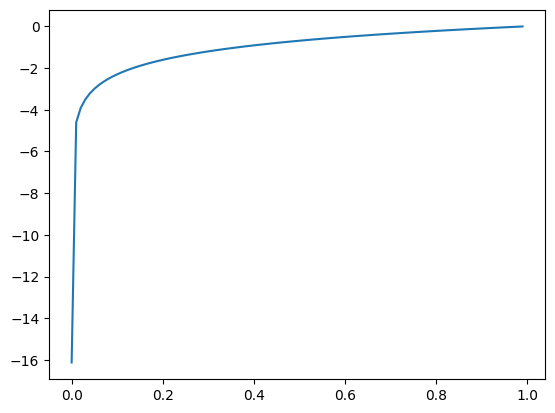

In [7]:
import matplotlib.pyplot as plt

x = np.arange(0.0, 1.0, 0.01)
delta = 1e-7
y = np.log(x + delta)

plt.plot(x, y)
plt.show()

In [12]:
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


print(x_train.shape)
print(y_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28)
(60000,)


In [17]:
y_train_one_hot = tf.keras.utils.to_categorical(y_train)
print(y_train_one_hot.shape)

x_train = x_train.reshape(60000, -1)
print(x_train.shape)

(60000, 10)
(60000, 784)


In [18]:
# 미니배치
train_size = x_train.shape[0]
batch_size = 10
batch_mask = np.random.choice(train_size, batch_size)
x_batch = x_train[batch_mask]
t_batch = y_train_one_hot[batch_mask]

print(batch_mask)

[46662  2468  8556 11439 57902 56137 27750 52015 27622 14841]


In [30]:
# 미니배치 Loss
def cross_entropy_error(y, t):
  if y.ndim == 1:
    t = t.reshape(1, t.size)
    y = y.reshape(1, y.size)

  batch_size = y.shape[0]
  return -np.sum(t * np.log(y + 1e-7)) / batch_size

# one hot encoding 이 아닐때
def cross_entropy_error(y, t):
  if y.ndim == 1:
    t = t.reshape(1, t.size)
    y = y.reshape(1, y.size)

  batch_size= y.shape[0]
  return -np.sum(np.log(y[np.arrange(batch_size), t] + 1e-7)) / batch_size


In [31]:
z = [[1, 2, 3, 4],
     [4, 5, 6, 7],
     [8, 9, 10, 11]]

z = np.array(z)

z[[0, 1, 2], [0, 1, 2]]
# z[0][0], z[1][1], z[2][2] 배열을 생

array([ 1,  5, 10])

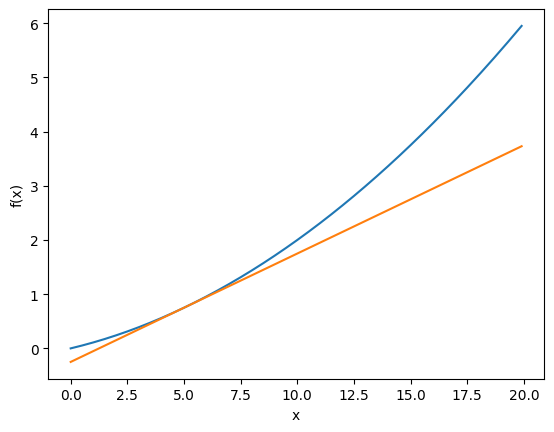

In [41]:
# 수치미분
def numerical_diff(f, x, option = 'c'):
  h = 1e-4 # 반올림 오차를 개선한 값

  if option == 'c':
    return (f(x+h) - f(x-h)) / (2*h)

  elif option == 'f':
    return (f(x+h) - f(x)) / h

  elif option == 'b':
    return (f(x-h) - f(x)) / h


def function_1(x):
  return 0.01 * x **2 + 0.1*x

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0.0, 20.0, 0.1)
y = function_1(x)

d = numerical_diff(function_1, 5)
b = function_1(5) - (d * 5)
y_d = d * x + b

plt.xlabel("x")
plt.ylabel('f(x)')
plt.plot(x, y)
plt.plot(x, y_d)
plt.show()


d = numerical_diff(function_1, 5)

